# KPI patterns de fraude détectés
Ce notebook calcule des KPI explicatifs pour les patterns décrits dans `fraud_detector.py`.


In [1]:
import pandas as pd
import numpy as np
import os

pd.options.display.max_columns = None
pd.options.display.max_rows = 20


In [2]:
## Charger le dataset et préparer les données
base_path = os.path.abspath('.')
paths = {
    'flagged': os.path.join(base_path, 'transactions_flagged.csv'),
    'scored': os.path.join(base_path, 'transactions_scored.csv'),
    'raw': os.path.join(base_path, 'transactions.csv'),
}

if os.path.exists(paths['flagged']):
    df = pd.read_csv(paths['flagged'], parse_dates=['timestamp'])
    label_column = 'is_fraud'
    source = 'transactions_flagged.csv'
elif os.path.exists(paths['scored']):
    df = pd.read_csv(paths['scored'], parse_dates=['timestamp'])
    label_column = 'flagged'
    source = 'transactions_scored.csv'
else:
    df = pd.read_csv(paths['raw'], parse_dates=['timestamp'])
    label_column = None
    source = 'transactions.csv'

print(f"Chargé depuis : {source}")
print(f"Transactions : {len(df)}")
print('Colonnes :', df.columns.tolist())
print('\nÉchantillon :')
df.head(5)


Chargé depuis : transactions_flagged.csv
Transactions : 1000
Colonnes : ['transaction_id', 'timestamp', 'card_id', 'amount', 'merchant_name', 'merchant_category', 'channel', 'cardholder_country', 'merchant_country', 'device_id', 'ip_address', 'fraud_score', 'reasons', 'is_fraud']

Échantillon :


,transaction_id,timestamp,card_id,amount,merchant_name,merchant_category,channel,cardholder_country,merchant_country,device_id,ip_address,fraud_score,reasons,is_fraud
0,tx_000784,2026-04-25 00:27:09,card_042,18.38,Amazon.ca,online_retail,online,US,CA,dev_33892b01,172.58.159.61,0.00,NaN,False
1,tx_000081,2026-04-25 00:32:37,card_004,160.55,Schwartz's,restaurant,in_person,CA,CA,NaN,NaN,0.35,amount $161 is 13x this card's median,False
2,tx_000389,2026-04-25 01:39:26,card_020,57.12,Chipotle,restaurant,in_person,US,US,NaN,NaN,0.00,NaN,False
3,tx_000779,2026-04-25 02:38:38,card_041,15.86,Videotron,utilities,online,CA,CA,dev_614ef198,142.112.31.70,0.00,NaN,False
4,tx_000256,2026-04-25 04:26:31,card_013,52.73,Shopify Merchant 2,online_retail,online,CA,CA,dev_e5c2222f,24.114.1.85,0.00,NaN,False


In [3]:
## Définir les fonctions de détection des patterns

class CardBaseline:
    def __init__(self, card_id, amounts, devices, ips, categories, home_country, phys_country):
        self.card_id = card_id
        self.amt_median = float(np.median(amounts))
        self.amt_mad = float(np.median(np.abs(amounts - self.amt_median))) * 1.4826
        self.devices = set(devices)
        self.ips = set(ips)
        self.categories = set(categories)
        self.home_country = home_country
        self.phys_country = phys_country
        self.n = len(amounts)

    def robust_z(self, amount):
        scale = max(self.amt_mad, 1.0)
        return (amount - self.amt_median) / scale


def build_baselines(df):
    baselines = {}
    for card, g in df.groupby('card_id'):
        phys = g[g['channel'].isin(['in_person', 'atm'])]
        home_country = g['cardholder_country'].mode().iloc[0]
        phys_country = phys['merchant_country'].mode().iloc[0] if len(phys) else home_country
        baselines[card] = CardBaseline(
            card,
            g['amount'].values,
            g['device_id'].dropna().unique(),
            g['ip_address'].dropna().unique(),
            g['merchant_category'].unique(),
            home_country,
            phys_country,
        )
    return baselines


BURST_WINDOW_MIN = 30
BURST_MIN_COUNT = 5
BURST_MAX_AMT = 20.0
CASHOUT_CATS = {'gift_card', 'electronics'}
CASHOUT_MIN_AMT = 250.0
MERCHANT_MULT = 5.0
MERCHANT_MIN_AMT = 200.0
MERCHANT_MIN_HITS = 3
AMOUNT_RZ_HI = 6.0


def detect_burst(df):
    bursts = []
    for card, g in df.groupby('card_id'):
        g = g.sort_values('timestamp')
        for i, row in g.iterrows():
            window = g[(g['timestamp'] >= row['timestamp']) &
                       (g['timestamp'] < row['timestamp'] + pd.Timedelta(minutes=BURST_WINDOW_MIN))]
            if len(window) >= BURST_MIN_COUNT and window['amount'].median() < BURST_MAX_AMT and (window['channel'] == 'online').all():
                bursts.append((card, len(window), float(window['amount'].median()), list(window['transaction_id'])))
                break
    return bursts


def detect_cashout(df, baselines):
    cashouts = []
    for _, row in df.iterrows():
        if row['merchant_category'] in CASHOUT_CATS and row['amount'] >= CASHOUT_MIN_AMT:
            z = baselines[row['card_id']].robust_z(row['amount'])
            cashouts.append((row['transaction_id'], row['card_id'], row['merchant_name'], row['merchant_category'], row['amount'], z))
    return cashouts


def detect_merchant_ring(df):
    ring = []
    for merch, g in df.groupby('merchant_name'):
        med = g['amount'].median()
        hi = g[(g['amount'] > MERCHANT_MULT * med) & (g['amount'] > MERCHANT_MIN_AMT)]
        if len(hi) >= MERCHANT_MIN_HITS and hi['card_id'].nunique() >= MERCHANT_MIN_HITS:
            ring.append((merch, len(hi), int(hi['card_id'].nunique()), float(med), float(hi['amount'].mean())))
    return ring


def detect_geo(df, baselines):
    mismatches = []
    phys = df[df['channel'].isin(['in_person', 'atm'])]
    for _, row in phys.iterrows():
        home = baselines[row['card_id']].home_country
        if row['merchant_country'] != home:
            mismatches.append((row['transaction_id'], row['card_id'], row['merchant_name'], row['merchant_country'], home, row['amount']))
    return mismatches


def detect_amount_outliers(df, baselines):
    outliers = []
    for _, row in df.iterrows():
        z = baselines[row['card_id']].robust_z(row['amount'])
        if z >= AMOUNT_RZ_HI:
            outliers.append((row['transaction_id'], row['card_id'], row['amount'], z, row['merchant_name'], row['channel']))
    return outliers


In [4]:
## Calculer les KPI pour chaque pattern
baselines = build_baselines(df)

bursts = detect_burst(df)
cashouts = detect_cashout(df, baselines)
merchant_rings = detect_merchant_ring(df)
geo_mismatches = detect_geo(df, baselines)
outliers = detect_amount_outliers(df, baselines)

print('Card-testing (burst) :')
print('Nombre de cartes avec burst :', len(bursts))
print('Transactions affectées par burst :', sum(n for _, n, _, _ in bursts))
print('Montant médian des bursts :', np.median([m for _, _, m, _ in bursts]) if bursts else None)
print()

print('Cashout :')
print('Nombre de transactions cashout :', len(cashouts))
print('Cartes impactées cashout :', len(set(card for _, card, *_ in cashouts)))
print('Montant moyen cashout :', np.mean([amt for *_, amt, _ in cashouts]) if cashouts else None)
print('Z-score moyen cashout :', np.mean([z for *_, z in cashouts]) if cashouts else None)
print()

print('Merchant ring :')
print('Nombre de marchands suspects :', len(merchant_rings))
print('Nombre total de cartes impliquées :', sum(card_count for *_, card_count, _, _ in merchant_rings))
print('Montant moyen par merchant_ring :', np.mean([mean_amt for *_, mean_amt in merchant_rings]) if merchant_rings else None)
print()

print('Impossible travel :')
print('Nombre de transactions geo mismatch :', len(geo_mismatches))
print('Nombre de cartes impactées geo :', len(set(card for _, card, *_ in geo_mismatches)))
print()

print('Outliers de montants individuels :')
print('Nombre de transactions outliers :', len(outliers))
print('Z-score moyen outliers :', np.mean([z for _, _, _, z, _, _ in outliers]) if outliers else None)
print('Montants outliers médian :', np.median([amt for _, _, amt, _, _, _ in outliers]) if outliers else None)


Card-testing (burst) :
Nombre de cartes avec burst : 4
Transactions affectées par burst : 39
Montant médian des bursts : 6.9525

Cashout :
Nombre de transactions cashout : 15
Cartes impactées cashout : 8
Montant moyen cashout : 1113.9046666666666
Z-score moyen cashout : 40.87004880747634

Merchant ring :
Nombre de marchands suspects : 2
Nombre total de cartes impliquées : 16
Montant moyen par merchant_ring : 516.2910714285714

Impossible travel :
Nombre de transactions geo mismatch : 3
Nombre de cartes impactées geo : 3

Outliers de montants individuels :
Nombre de transactions outliers : 54
Z-score moyen outliers : 24.6543125914883
Montants outliers médian : 425.90999999999997


In [5]:
## KPI supplémentaires : montants max, fréquence, diversité

card_stats = df.groupby('card_id').agg(
    trans_count=('transaction_id', 'count'),
    max_amount=('amount', 'max'),
    avg_amount=('amount', 'mean'),
    unique_merchants=('merchant_name', 'nunique'),
    unique_categories=('merchant_category', 'nunique'),
)

card_stats['max_amount_z'] = (card_stats['max_amount'] - card_stats['max_amount'].mean()) / card_stats['max_amount'].std(ddof=0)
card_stats['merchant_diversity'] = card_stats['unique_merchants'] / card_stats['trans_count']
card_stats['category_diversity'] = card_stats['unique_categories'] / card_stats['trans_count']
card_stats['high_freq'] = card_stats['trans_count'] >= card_stats['trans_count'].quantile(0.80)
card_stats['high_max_spike'] = card_stats['max_amount_z'] >= 2

print('Pics de montants max :')
print(card_stats.sort_values('max_amount', ascending=False)[['max_amount', 'max_amount_z']].head(5))
print()

print('Fréquence anormale : cartes top 20% par transaction count')
print(card_stats[card_stats['high_freq']].sort_values('trans_count', ascending=False).head(10))
print()

print('Incohérence de diversité :')
print(card_stats.sort_values('merchant_diversity').head(5)[['trans_count', 'unique_merchants', 'merchant_diversity']])
print(card_stats.sort_values('category_diversity').head(5)[['trans_count', 'unique_categories', 'category_diversity']])
print()

print('Cartes high max spike :', card_stats['high_max_spike'].sum())
print('Cartes à diversité faible et score élevé :', len(card_stats[(card_stats['merchant_diversity'] < 0.2) | (card_stats['category_diversity'] < 0.1)]))


Pics de montants max :
          max_amount  max_amount_z
card_id                           
card_016     1900.28      3.179398
card_018     1753.33      2.855136
card_020     1474.93      2.240815
card_045     1274.84      1.799293
card_021     1148.20      1.519848

Fréquence anormale : cartes top 20% par transaction count
          trans_count  max_amount  avg_amount  unique_merchants  \
card_id                                                           
card_038           29      356.29   28.446552                16   
card_042           29       98.03   22.184483                14   
card_023           28      106.90   19.327143                12   
card_020           27     1474.93  159.583704                18   
card_049           27      536.35   49.066296                12   
card_037           25      399.49   93.303200                15   
card_008           23       96.96   33.532174                18   
card_036           23      614.82   94.307826                18   
car

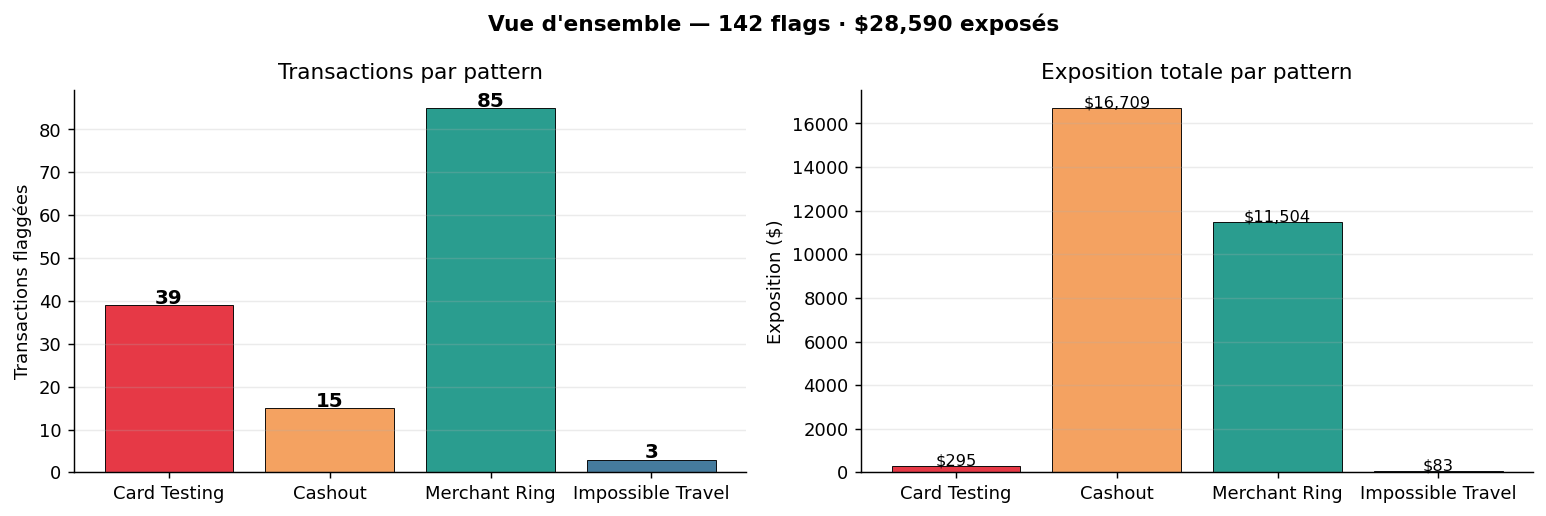

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

pattern_labels = ["Card Testing", "Cashout", "Merchant Ring", "Impossible Travel"]
colors = ["#E63946", "#F4A261", "#2A9D8F", "#457B9D"]

burst_tids  = {tid for _, _, _, tids in bursts for tid in tids}
cashout_tids = {row[0] for row in cashouts}
ring_tids    = set(df[df["merchant_name"].isin([r[0] for r in merchant_rings])]["transaction_id"])
geo_tids     = {row[0] for row in geo_mismatches}

counts    = [len(burst_tids), len(cashout_tids), len(ring_tids), len(geo_tids)]
exposures = [
    df[df["transaction_id"].isin(burst_tids)]["amount"].sum(),
    df[df["transaction_id"].isin(cashout_tids)]["amount"].sum(),
    df[df["transaction_id"].isin(ring_tids)]["amount"].sum(),
    df[df["transaction_id"].isin(geo_tids)]["amount"].sum(),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bars1 = ax1.bar(pattern_labels, counts, color=colors, edgecolor="black", lw=0.5)
for b, v in zip(bars1, counts):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, str(v),
             ha="center", fontweight="bold", fontsize=11)
ax1.set(ylabel="Transactions flaggées", title="Transactions par pattern")
ax1.grid(axis="y", alpha=0.25)

bars2 = ax2.bar(pattern_labels, exposures, color=colors, edgecolor="black", lw=0.5)
for b, v in zip(bars2, exposures):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 10, f"${v:,.0f}",
             ha="center", fontsize=9)
ax2.set(ylabel="Exposition ($)", title="Exposition totale par pattern")
ax2.grid(axis="y", alpha=0.25)

plt.suptitle(f"Vue d'ensemble — {sum(counts)} flags · ${sum(exposures):,.0f} exposés", fontweight="bold")
plt.tight_layout()
plt.show()

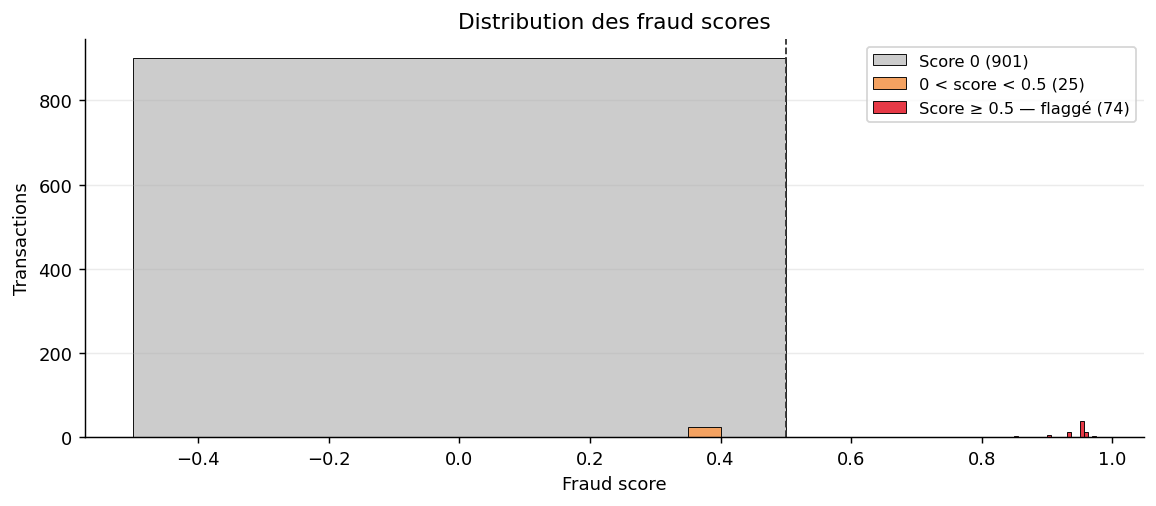

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

legit  = df[df["fraud_score"] == 0]["fraud_score"]
sus    = df[(df["fraud_score"] > 0) & (df["fraud_score"] < 0.5)]["fraud_score"]
flagged = df[df["fraud_score"] >= 0.5]["fraud_score"]

ax.hist(legit,   bins=1,  color="#CCC",     edgecolor="black", lw=0.5, label=f"Score 0 ({len(legit)})")
ax.hist(sus,     bins=20, color="#F4A261",  edgecolor="black", lw=0.5, label=f"0 < score < 0.5 ({len(sus)})")
ax.hist(flagged, bins=20, color="#E63946",  edgecolor="black", lw=0.5, label=f"Score ≥ 0.5 — flaggé ({len(flagged)})")
ax.axvline(0.5, color="#333", ls="--", lw=1)
ax.set(xlabel="Fraud score", ylabel="Transactions", title="Distribution des fraud scores")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

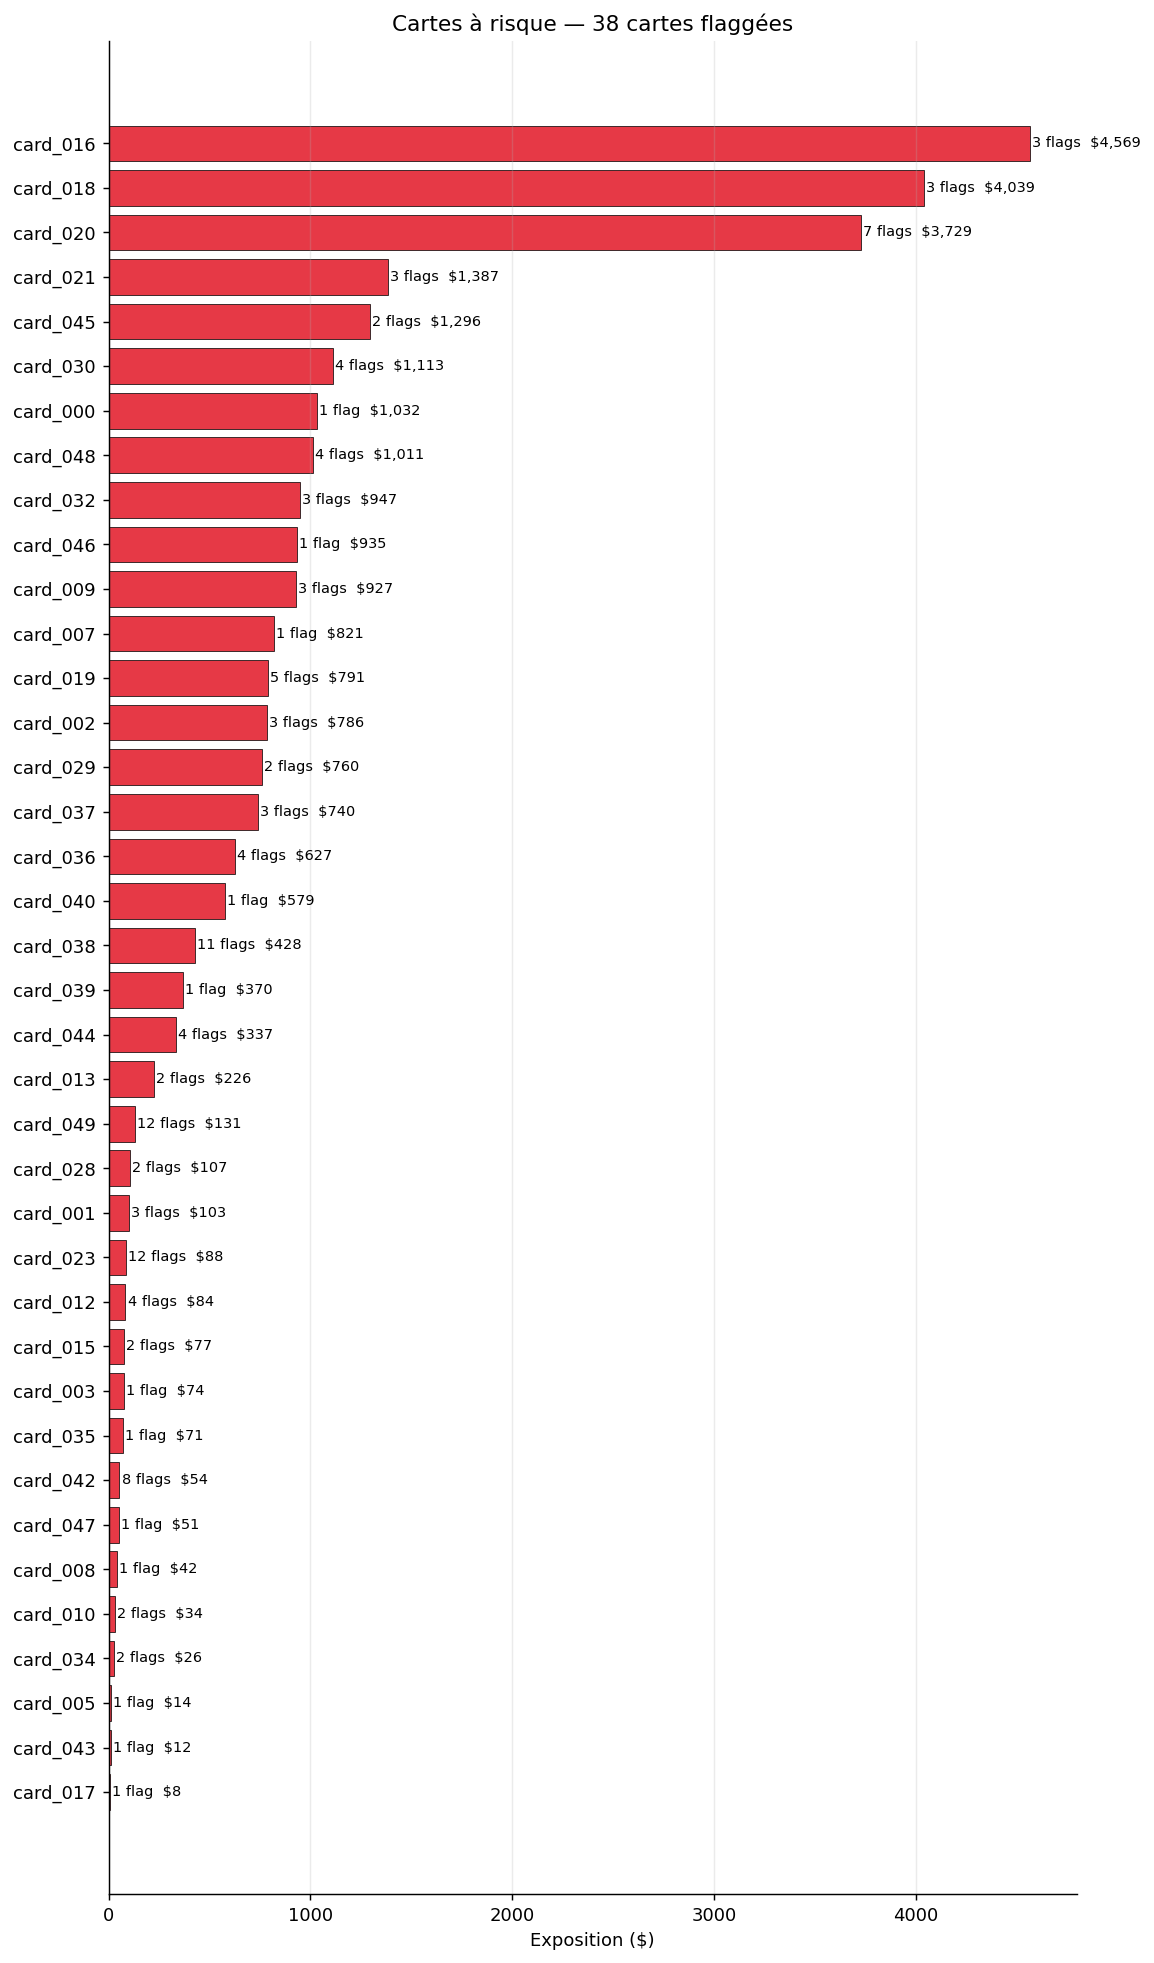

In [8]:
all_flagged = burst_tids | cashout_tids | ring_tids | geo_tids
card_risk = (df[df["transaction_id"].isin(all_flagged)]
             .groupby("card_id")
             .agg(n_flags=("transaction_id", "count"), exposure=("amount", "sum"))
             .sort_values("exposure"))

fig, ax = plt.subplots(figsize=(9, max(4, len(card_risk) * 0.4)))
bars = ax.barh(card_risk.index, card_risk["exposure"], color="#E63946", edgecolor="black", lw=0.4)
for bar, (_, row) in zip(bars, card_risk.iterrows()):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f"{int(row['n_flags'])} flag{'s' if row['n_flags']>1 else ''}  ${row['exposure']:,.0f}",
            va="center", fontsize=8)
ax.set(xlabel="Exposition ($)", title=f"Cartes à risque — {len(card_risk)} cartes flaggées")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()